PROGRAMA PARA PROCESAMIENTO DE ESPECTROS
CARACTERIZACION DE LA FIRMA ESPECTRAL
SATREPS - F7 (Fase 7). PROYECTO MINCIENCIAS
PROCESANDO ESPECTRO

In [34]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import os

1. CARGAR ARCHIVO DESDE DIRECTORIO

In [35]:
%matplotlib inline
%config InlineBackend.figure_format='retina'
plt.style.use('ggplot')

a=r'C:\Users\Asus\Documents\AGROSAVIA_2024\BASE_DATOS_MGSN5\EXPERIMENTAL_DATA_MGSN5\1-16Ag2024\Spectrum\5'
os.chdir(a)
os.listdir(a)

['Reflection__10__07-47-04-960.txt',
 'Reflection__11__07-47-38-863.txt',
 'Reflection__8__07-46-44-403.txt',
 'Reflection__9__07-46-53-848.txt',
 'SpectralSignature.csv',
 'SpectralSignature.cvs',
 'SpectralSignatureLOG.csv']

2. GRÁFICO DEL ESPECTRO

C:\Users\Asus\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\Asus\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\Asus\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating 

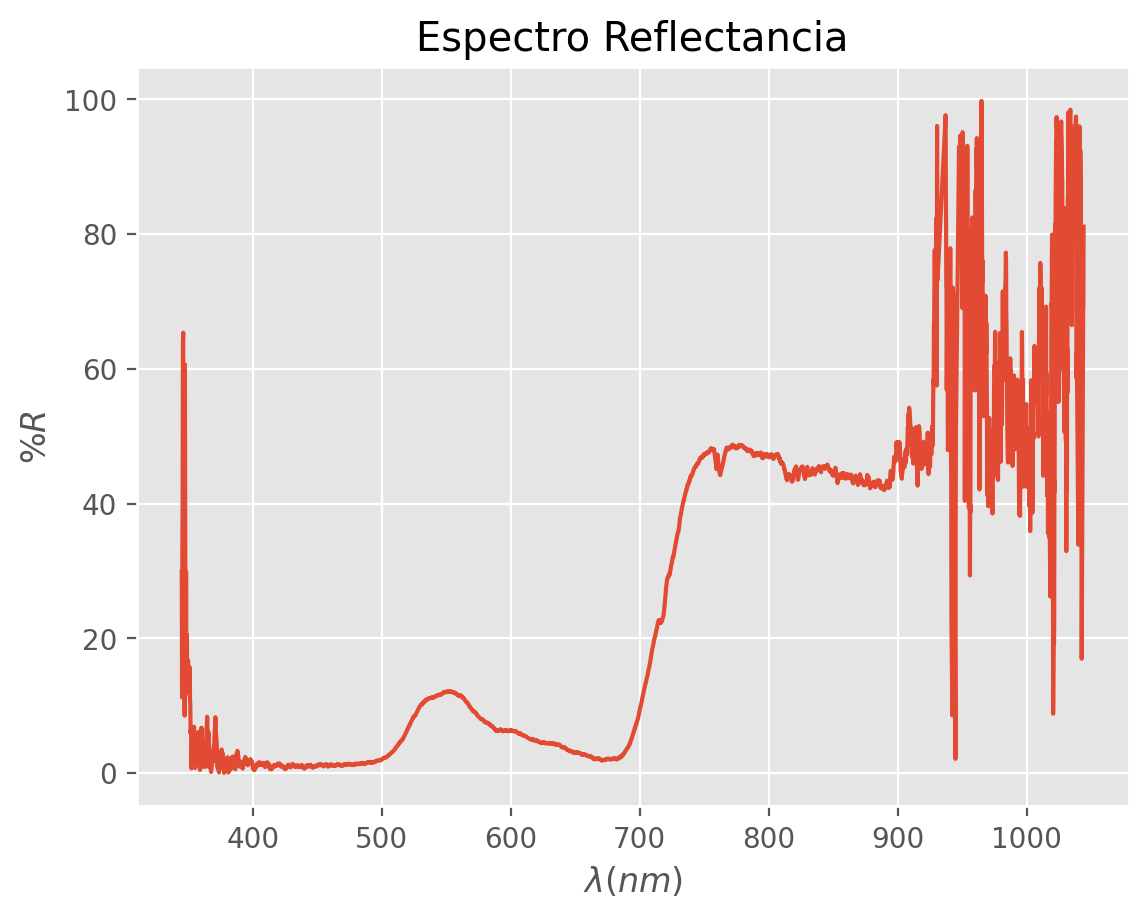

In [36]:
Map = {"column_1":"lambda(nm)","column_2":"%R"}

def MapElements(t):
    return t[0].replace(",","."),t[1].replace(",",".")

Data = pl.scan_csv("Reflection__10__07-47-04-960.txt",skip_rows=14,has_header=False,separator="\t").rename(Map).with_columns(
pl.col("lambda(nm)").str.replace(",",".").cast(pl.Float32) , pl.col("%R").str.replace(",",".").cast(pl.Float32) ).filter(
(pl.col("%R") <= 100) & (pl.col("%R") >= 0) )
sns.lineplot(data=Data.collect(),x="lambda(nm)",y="%R")
plt.xlabel(r"$\lambda (nm)$")
plt.ylabel(r"$\%R$")
plt.title("Espectro Reflectancia")
plt.show()

C:\Users\Asus\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\polars\series\series.py:1167: RuntimeWarning: invalid value encountered in log10
  series = f(lambda out: ufunc(*args, out=out, dtype=dtype_char, **kwargs))
C:\Users\Asus\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\Asus\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\

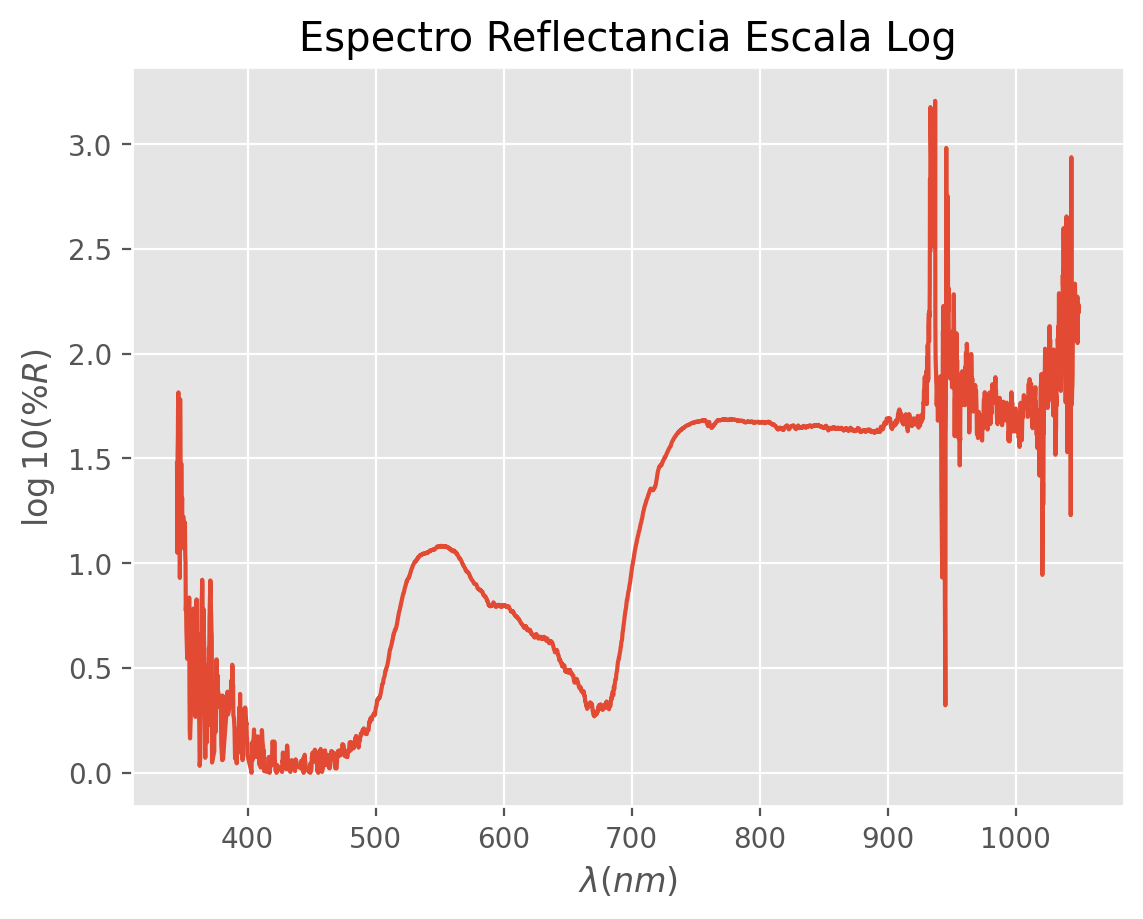

In [37]:
Data = pl.scan_csv("Reflection__10__07-47-04-960.txt",skip_rows=14,has_header=False,separator="\t").rename(Map).with_columns(
pl.col("lambda(nm)").str.replace(",",".").cast(pl.Float32) , np.log10(pl.col("%R").str.replace(",",".").cast(pl.Float32) )).filter(
(pl.col("%R") <= 100) & (pl.col("%R") >= 0) )
sns.lineplot(data=Data.collect(),x="lambda(nm)",y="%R")
plt.xlabel(r"$\lambda (nm)$")
plt.ylabel(r"$\log10(\%R)$")
plt.title("Espectro Reflectancia Escala Log")
plt.show()

3. LECTURA DE DATOS DEL ESPECTRO

In [38]:
Data_Spectrum = pl.read_csv("Reflection__10__07-47-04-960.txt",skip_rows=14,has_header=False,separator="\t").rename(Map).with_columns(
pl.col("lambda(nm)").str.replace(",",".").cast(pl.Float32) , pl.col("%R").str.replace(",",".").cast(pl.Float32) ).filter(
(pl.col("%R") <= 100) & (pl.col("%R") >= 0) )

4. CALCULO DE VALORES DE REFLECTANCIA A LONGITUDES DE ONDA DE INTERES

In [39]:
DataSpectrum=Data_Spectrum.to_numpy()
#REFLECTANCIA
R840=np.mean(DataSpectrum[(np.where((DataSpectrum[:,0] <= 850) & ( 840 <= DataSpectrum[:,0] ))),1])/100 #NIR
R668=np.mean(DataSpectrum[(np.where((DataSpectrum[:,0] <= 678) & ( 660 <= DataSpectrum[:,0] ))),1])/100 #RED (R)
R717=np.mean(DataSpectrum[(np.where((DataSpectrum[:,0] <= 727) & ( 707 <= DataSpectrum[:,0] ))),1])/100 #REDEDGE
R560=np.mean(DataSpectrum[(np.where((DataSpectrum[:,0] <= 570) & ( 550 <= DataSpectrum[:,0] ))),1])/100 #GREEN (G)
R450=np.mean(DataSpectrum[(np.where((DataSpectrum[:,0] <= 495) & ( 450 <= DataSpectrum[:,0] ))),1])/100 #BLUE (B)

5. CALCULO DE INDICES DE VEGETACIÓN 
5.1. LOS QUE "COINCIDEN" CON LOS DE DRON COMERCIAL (3)

In [40]:
NDVI=round((R840-R668) / (R840+R668),3)
GNDVI=round((R840-R560) / (R840+R560),3)
NDRED= round((R717-R668)/(R717+R668),3)

5.2. OTROS INDICES DE VEGETACIÓN (26)

In [41]:
#Factores
L_fact=0.5 #L=1 baja veg, 0.5 media y 0 alta
R_red_blue=R668-1*(R668-R450)
#INDICES 
SRI=round(R668/R840,3)
TVI=round(np.sqrt(NDVI-0.5),3)
SAVI= round((1+L_fact)*(R840-R668) / (R840+R668+L_fact),3)
OSAVI= round((R840-R668) / (R840+R668+0.16),3)
ARVI=round((R840-R_red_blue) / (R840+R_red_blue),3)
SARVI=round((1+L_fact)*(R840-R_red_blue) / (R840+R_red_blue+L_fact),3)
SARVI2=round(2.5*(1+L_fact)*(R840-R668)/(R840-6*R668-7.5*R668+L_fact),3)
EVI2=round(2.5*(R840-R668)/(R840-2.4*R668 +L_fact),3)
NLI=round((R840**2-R668) / (R840**2+R668),3)
VARI=round((R560-R668) / (R560+R668-R450),3)
CLGR=round((R840/R560)-1,3)  #Chlorofyl Index Green
CLRE=round((R840/R717)-1,3)  #Chlorofyl Index Red Edge
NDWI=round((R840-R560) / (R840+R560),3)
RDVI=round((R840-R560) / np.sqrt(R840+R560),3)
WDRVI=round((0.1*R840-R560) / (0.1*R840+R560),3)
NGRVI=round((R560-R668)/(R560-R668),3)
GRVI=round((R560**2-R668**2)/(R560**2-R668**2),3)
LAI=round(3.618*SARVI-0.118, 3)  #Leaf Area Index
ARI1=round((1/R560) -(1/R717),3)
ARI2=round(R840*((1/R560) -(1/R717)),3)
BGI=round(R450/R560,3)
BRI=round(R450/R668,3)
NPCI=round((R560-R668)/(R560-R668),3) #normalized pigment chrolofyll RI
NPQI=round((R668-R450) / (R668+R450),3)
PSRI=round(R668-R560/R717,3)   #Plant Senescence reflectance Index
SIPI=round(R840-R450/(R840-R668),3)

6. SPECTRUM SLICING: CALCULO DE PENDIENTE EN LONGITUD DE ONDA REDEDGE

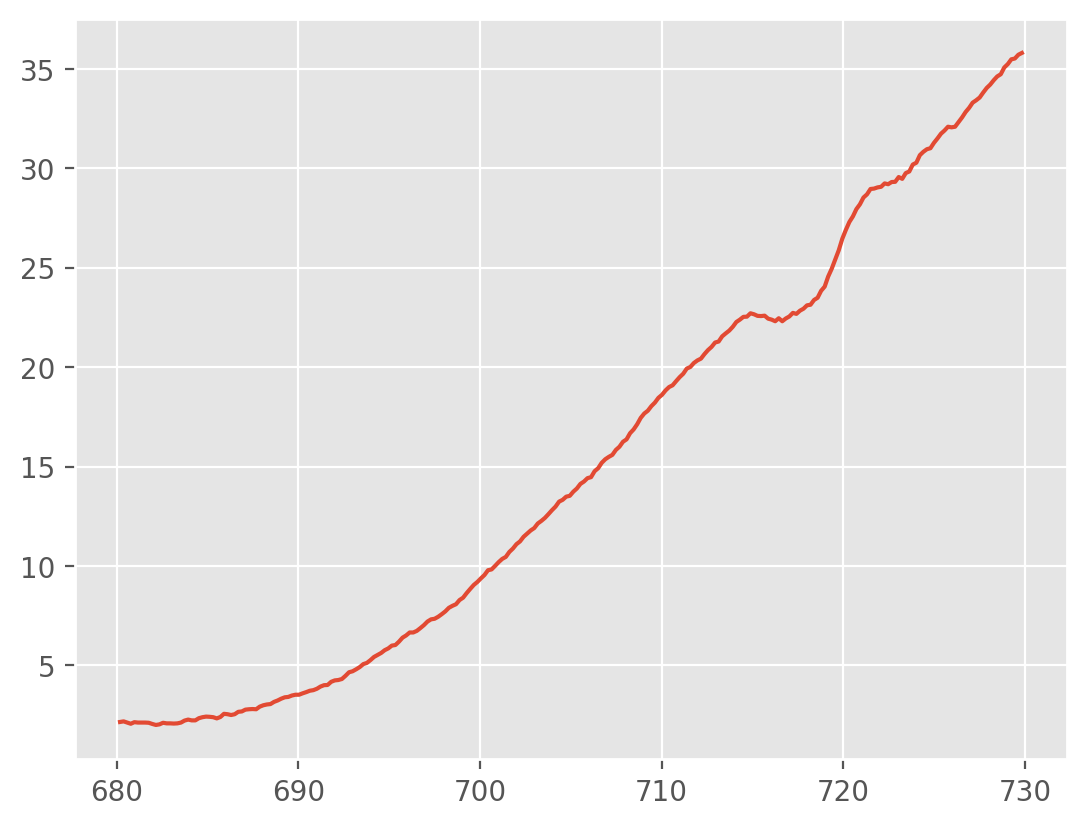

In [42]:
indexRslope=(np.where((DataSpectrum[:,0] <= 730) & ( 680 <= DataSpectrum[:,0] )))
lambdaSlope_REDEDGE=DataSpectrum[indexRslope,0]
RSlope_REDEDGE=DataSpectrum[indexRslope,1]
Slope_REDEDEGE=(RSlope_REDEDGE[:,0] - RSlope_REDEDGE[:,-1])/(lambdaSlope_REDEDGE[:,0] - lambdaSlope_REDEDGE[:,-1])
plt.plot(lambdaSlope_REDEDGE[:,:][0,:], RSlope_REDEDGE[:,:][0,:])
plt.show()

7.SPECTRUM SLICING: CALCULO DE LONGITUD DE ONDA EN EL VERDE (GREEN: G)

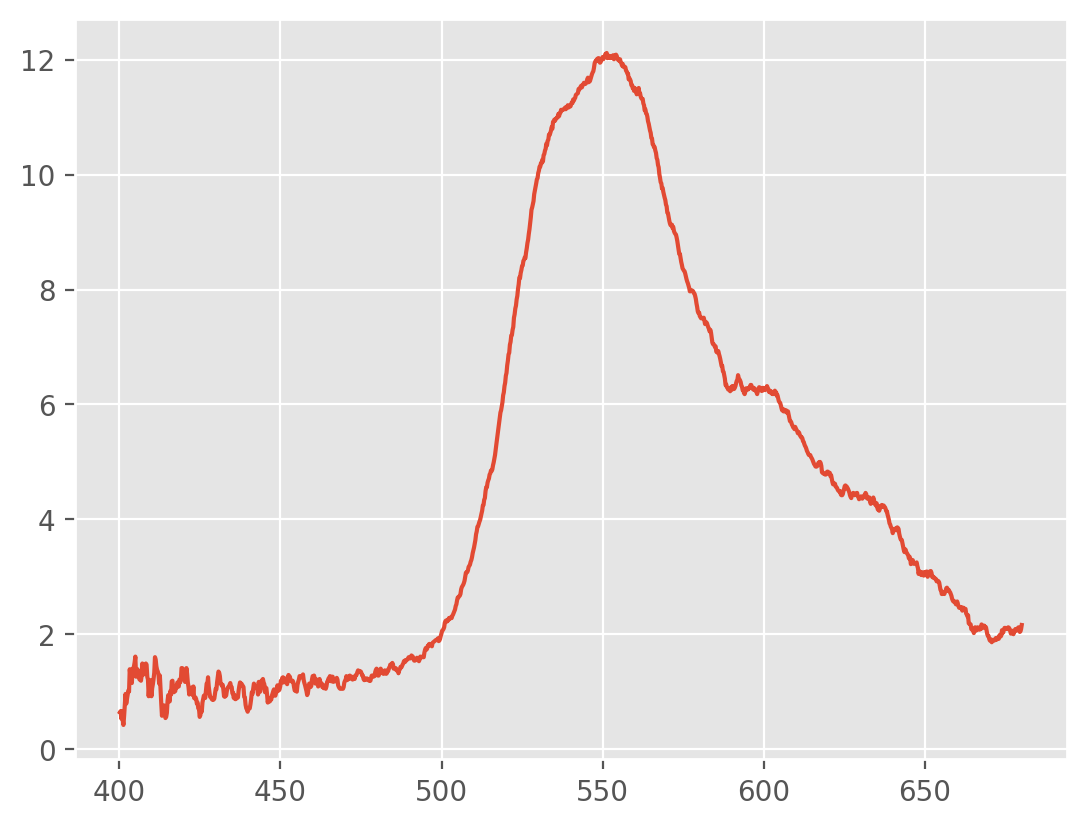

In [43]:
indexRPeakGREEN=(np.where((DataSpectrum[:,0] <= 680) & ( 400 <= DataSpectrum[:,0] )))
lambdaPeak_GREEN=DataSpectrum[indexRPeakGREEN,0]
RData_GREEN=DataSpectrum[indexRPeakGREEN,1]
PeakMaxGREEN=np.array(np.max(RData_GREEN), dtype='float64')*1E-2
index_lambdaMaxGREEN=(np.where(RData_GREEN[:,:][0,:] == PeakMaxGREEN))
PeakGreen=np.round(lambdaPeak_GREEN[:,:][0,index_lambdaMaxGREEN])
plt.plot(lambdaPeak_GREEN[:,:][0,:], RData_GREEN[:,:][0,:])
plt.show()

CARACTERIZACION DE LA FIRMA ESPECTRAL CON:
INDICES DE VEGETACIÓN
REFLECTANCIA: RED, GREEN, BLUE, NIR
REFLECTANCIA EN EL PICO DEL VERDE= RMAXG
PENDIENTE EN BORDE ROJO: REDEDGE_SLOPE


In [44]:
Spectral_Signature=np.array([[NDVI], [NDRED], [GNDVI], [SRI],[TVI],[SAVI],[OSAVI],[ARVI],[SARVI],
                             [SARVI2],[EVI2],[NLI],[VARI],[CLGR],[CLRE],[NDWI],[RDVI],[WDRVI],[NGRVI],
                             [GRVI],[LAI],[ARI1],[ARI2],[BGI],[BRI],[NPCI], [NPQI], [PSRI], [SIPI], 
                             [R668*100], [R560*100], [R450*100], [R840*100], 
                             [PeakMaxGREEN*100], [float(Slope_REDEDEGE)]], dtype='float64')
np.savetxt('SpectralSignature.cvs', np.array(Spectral_Signature).T, delimiter=",", header='NDVI, NDRED,GNDVI,SRI,TVI,SAVI,OSAVI,ARVI,SARVI,SARVI2,EVI2,NLI,VARI,CLGR,CLRE,NDWI,RDVI,WDRVI,NGRVI,GRVI,LAI,ARI1,ARI2,BGI,BRI,NPCI, NPQI, PSRI, SIPI, R668, R560, R450, R840, PeakMaxGREEN, Slope_REDEDGE', fmt='%1f')
print(Spectral_Signature)

[[ 0.91      ]
 [ 0.839     ]
 [ 0.6       ]
 [ 0.047     ]
 [ 0.64      ]
 [ 0.663     ]
 [ 0.68      ]
 [ 0.945     ]
 [ 0.682     ]
 [ 2.422     ]
 [ 1.194     ]
 [ 0.812     ]
 [ 0.757     ]
 [ 3.003     ]
 [ 0.87      ]
 [ 0.6       ]
 [ 0.451     ]
 [-0.428     ]
 [ 1.        ]
 [ 1.        ]
 [ 2.349     ]
 [ 4.727     ]
 [ 2.133     ]
 [ 0.114     ]
 [ 0.609     ]
 [ 1.        ]
 [ 0.243     ]
 [-0.446     ]
 [ 0.421     ]
 [ 2.1146667 ]
 [11.2697916 ]
 [ 1.28725123]
 [45.11109543]
 [12.11999989]
 [ 0.67780244]]


C:\Users\Asus\AppData\Local\Temp\ipykernel_9296\2538696567.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  [PeakMaxGREEN*100], [float(Slope_REDEDEGE)]], dtype='float64')


In [46]:
Spectral_SignatureLOG=np.array([[NDVI], [NDRED], [GNDVI], [SRI],[TVI],[SAVI],[OSAVI],[ARVI],[SARVI],
                                [SARVI2],[EVI2],[NLI],[VARI],[CLGR],[CLRE],[NDWI],[RDVI],[WDRVI],
                                [NGRVI],[GRVI],[LAI],[ARI1],[ARI2],[BGI],[BRI],[NPCI], [NPQI], 
                                [PSRI], [SIPI], [10*np.log10(R668*100)], [10*np.log10(R560*100)], 
                                [10*np.log10(R450*100)],[10*np.log10(R840*100)], [10*np.log10(PeakMaxGREEN*100)], 
                                [float(Slope_REDEDEGE)]], dtype='float64')
np.savetxt('SpectralSignatureLOG.csv', np.array(Spectral_Signature).T, delimiter=",", header='NDVI, NDRED,  GNDVI,SRI,TVI,SAVI,OSAVI,ARVI,SARVI,SARVI2,EVI2,NLI,VARI,CLGR,CLRE,NDWI,RDVI,WDRVI,NGRVI,GRVI,LAI,ARI1,ARI2,BGI,BRI,NPCI, NPQI, PSRI, SIPI, log10(R668), log10(R560), log10(R450), log10(R840), PeakMaxGREEN, Slope_REDEDGE', fmt='%1f')
print(Spectral_SignatureLOG)

[[ 0.91      ]
 [ 0.839     ]
 [ 0.6       ]
 [ 0.047     ]
 [ 0.64      ]
 [ 0.663     ]
 [ 0.68      ]
 [ 0.945     ]
 [ 0.682     ]
 [ 2.422     ]
 [ 1.194     ]
 [ 0.812     ]
 [ 0.757     ]
 [ 3.003     ]
 [ 0.87      ]
 [ 0.6       ]
 [ 0.451     ]
 [-0.428     ]
 [ 1.        ]
 [ 1.        ]
 [ 2.349     ]
 [ 4.727     ]
 [ 2.133     ]
 [ 0.114     ]
 [ 0.609     ]
 [ 1.        ]
 [ 0.243     ]
 [-0.446     ]
 [ 0.421     ]
 [ 3.25241927]
 [10.51915885]
 [ 1.09663317]
 [16.54283373]
 [10.83502616]
 [ 0.67780244]]


C:\Users\Asus\AppData\Local\Temp\ipykernel_9296\2733518888.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  [float(Slope_REDEDEGE)]], dtype='float64')
